<a href="https://colab.research.google.com/github/KIISIISHERE/Simple-Digit-Predictor-Using-Deep-Learning/blob/main/Simple_Digit_Predictor_Using_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf #building the neural network
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [2]:
#load the data
(x_train, y_train),(x_test, y_test)=tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
#normalize the data
x_train=x_train/255.0
x_test=x_test/255.0

In [4]:
#build the model
model = models.Sequential([
    #first layer
    layers.Flatten(input_shape=(28, 28)),#28 by 28 pixels and converted into id
    #Dense layer-work on data
    layers.Dense(128, activation='relu'),
    #output layer-predictions
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [5]:
#compile the model
model.compile(
    optimizer='adam',#adjust the weights efficiently
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'] #evaluate the model's performance
)

In [6]:
#train the model
model.fit(
    x_train, y_train,
    epochs=50,
    validation_data=(x_test, y_test)
    )

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9286 - loss: 0.2523 - val_accuracy: 0.9537 - val_loss: 0.1508
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9664 - loss: 0.1127 - val_accuracy: 0.9655 - val_loss: 0.1112
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9761 - loss: 0.0782 - val_accuracy: 0.9737 - val_loss: 0.0825
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9815 - loss: 0.0601 - val_accuracy: 0.9714 - val_loss: 0.0944
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9861 - loss: 0.0455 - val_accuracy: 0.9765 - val_loss: 0.0812
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9882 - loss: 0.0373 - val_accuracy: 0.9754 - val_loss: 0.0784
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9905 - loss: 0.0295 - val_accuracy: 0.9780 - val_loss: 0.0741
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9924 - loss: 0.0238 

In [7]:
#Evaluate the model
test_loss, test_acc=model.evaluate(x_test,y_test)
print(f"Test accuracy: {test_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9800 - loss: 0.1676
Test accuracy: 0.9800000190734863


In [8]:
#make prediction
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


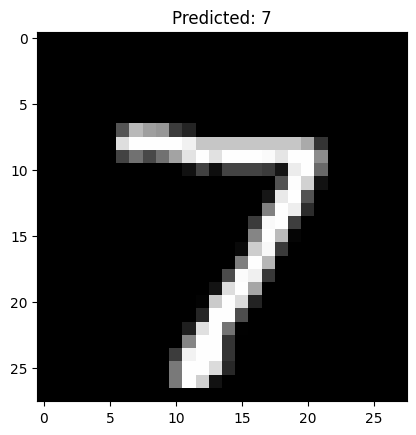

In [11]:
predicted_digit = predictions[0].argmax()
plt.imshow(x_test[0], cmap='gray')#display the 1st testing digit
plt.title(f"Predicted: {predicted_digit}") # Display the predicted digit as a title
plt.show()